# Testing the implementation of biLSTM

In [1]:
from tensorflow.python.client import device_lib
print("\n".join([x.name for x in device_lib.list_local_devices()]))


/device:CPU:0
/device:GPU:0


## Load required libraries

In [1]:
import random, numpy as np, tensorflow as tf
import os
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, Input, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import random
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Set global seed to control randomness

In [2]:

seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

tf.config.experimental.enable_op_determinism()


# Preprocessing

In [3]:

data = np.load("../preprocessing/ready/squat_sequences__normalized.npz")

X_data = data["X"]
y_labels = data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train[0].shape, X_test[0].shape, y_train[0], y_test[0])

# Pick an example (e.g. the first one)
idx = 0
sample = X_train[idx]
label = y_train[idx]

# Show some rows
print(f"\n▶️ Sample index: {idx} — Label: {label}")
print("First 10 frames:")
for i, row in enumerate(sample[:200]):
    print(f"Frame {i}: {row}")

(201, 189, 6) (51, 189, 6) (201,) (51,)
(189, 6) (189, 6) 0 1

▶️ Sample index: 0 — Label: 0
First 10 frames:
Frame 0: [0.999792   0.9993918  0.10432774 0.07054959 0.19903046 0.3014571 ]
Frame 1: [0.99863565 0.99975383 0.10386012 0.07445703 0.2003268  0.30363864]
Frame 2: [0.9982412  0.9993273  0.10386451 0.07955153 0.19436377 0.304408  ]
Frame 3: [0.9982196  0.9994093  0.10413606 0.07467967 0.19450092 0.3043189 ]
Frame 4: [0.99881816 0.9998013  0.10441231 0.07091763 0.19034612 0.3051616 ]
Frame 5: [0.99930274 0.9994147  0.10425361 0.06216095 0.18414944 0.30595592]
Frame 6: [0.99931073 0.9984672  0.10394725 0.06066118 0.18110001 0.30511096]
Frame 7: [0.9993248  0.9982629  0.10384146 0.06002111 0.18286878 0.2993233 ]
Frame 8: [0.99958813 0.9976624  0.10368808 0.06596459 0.18370426 0.2968694 ]
Frame 9: [0.9995632  0.9976928  0.10351812 0.08334745 0.1890819  0.29627842]
Frame 10: [0.9996642  0.99787354 0.10366719 0.08741461 0.19410622 0.29630888]
Frame 11: [0.9956962  0.9966457  0.1038043

# Processing with augmented Data

In [ ]:
# Load preprocessed augmented train/test sets
train_data = np.load("../preprocessing/Augmented_LSTM/squat_sequences_train.npz")
test_data = np.load("../preprocessing/Augmented_LSTM/squat_sequences_test.npz")

X_train = train_data["X"]
y_train = train_data["y"]
X_test = test_data["X"]
y_test = test_data["y"]

print(f" Loaded: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")
print(f" Input shape: {X_train.shape[1:]} (sequence_len, features)")
print(f" Example label: {y_train[0]}")

# Pick an example (e.g. the first one)
idx = 0
sample = X_train[idx]
label = y_train[idx]

# Show some rows
print(f"\n▶️ Sample index: {idx} — Label: {label}")
print("First 10 frames:")
for i, row in enumerate(sample[:200]):
    print(f"Frame {i}: {row}")

 Loaded: 804 training samples, 51 test samples
 Input shape: (189, 6) (sequence_len, features)
 Example label: 0

▶️ Sample index: 0 — Label: 0
First 10 frames:
Frame 0: [0.999792   0.9993918  0.10432774 0.07054959 0.03273576 0.3014571 ]
Frame 1: [0.99863565 0.99975383 0.10386012 0.07445703 0.03430128 0.30363864]
Frame 2: [0.9982412  0.9993273  0.10386451 0.07955153 0.02710027 0.304408  ]
Frame 3: [0.9982196  0.9994093  0.10413606 0.07467967 0.02726585 0.3043189 ]
Frame 4: [0.99881816 0.9998013  0.10441231 0.07091763 0.02224845 0.3051616 ]
Frame 5: [0.99930274 0.9994147  0.10425361 0.06216095 0.0147652  0.30595592]
Frame 6: [0.99931073 0.9984672  0.10394725 0.06066118 0.01108271 0.30511096]
Frame 7: [0.9993248  0.9982629  0.10384146 0.06002111 0.01321864 0.2993233 ]
Frame 8: [0.99958813 0.9976624  0.10368808 0.06596459 0.01422763 0.2968694 ]
Frame 9: [0.9995632  0.9976928  0.10351812 0.08334745 0.02072173 0.29627842]
Frame 10: [0.9996642  0.99787354 0.10366719 0.08741461 0.02678919 0.2

# Defined model Function

In [4]:


def create_bilstm_model(input_shape, lstm_units=128, dropout_rate=0.2, learning_rate=0.0005):
    model = Sequential([
        Input(shape=input_shape),
        Masking(mask_value=0.0),
        Bidirectional(LSTM(lstm_units, return_sequences=True)), # Use return_sequences=True for stacking layers
        GlobalMaxPooling1D(), # Use GlobalMaxPooling1D to reduce dimensionality
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Random search - Hyperparameter tuning

In [5]:
# Sample hyperparameters
def sample_params():
    return {
        "lstm_units": lambda: random.randint(50, 150),
        "dropout_rate": lambda: random.uniform(0.2, 0.5),
        "learning_rate": lambda: random.uniform(0.0001, 0.001),
        "batch_size": 32,  # fixed based on past good runs
        "epochs": lambda: random.randint(50, 100)  # fixed to ensure convergence
    }

# Run 5 trials of 3-fold CV
results = []
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for trial in range(5):
    # Call the lambda functions to get actual values
    params = {key: (value() if callable(value) else value) for key, value in sample_params().items()}
    print(f"\nTrial {trial+1} | Params: {params}")
    
    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

        model = create_bilstm_model(
            input_shape=(X_train.shape[1], X_train.shape[2]),
            lstm_units=params["lstm_units"],
            dropout_rate=params["dropout_rate"],
            learning_rate=params["learning_rate"]
        )

        model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            verbose=0
        )

        _, val_acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        print(f"  Fold {fold} accuracy: {val_acc:.4f}")
        fold_accuracies.append(val_acc)

    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    print(f"  Mean CV Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")

    results.append({**params, "cv_accuracy": mean_acc, "std": std_acc})

# Sort and display
results_df = pd.DataFrame(results).sort_values(by="cv_accuracy", ascending=False)
print(results_df.head())


Trial 1 | Params: {'lstm_units': 131, 'dropout_rate': 0.23339932044970413, 'learning_rate': 0.0007673954497838496, 'batch_size': 32, 'epochs': 65}
  Fold 1 accuracy: 0.8507
  Fold 2 accuracy: 0.8507
  Fold 3 accuracy: 0.9403
  Mean CV Accuracy: 0.8806 ± 0.0422

Trial 2 | Params: {'lstm_units': 79, 'dropout_rate': 0.3516065864310087, 'learning_rate': 0.00012388237271547726, 'batch_size': 32, 'epochs': 62}
  Fold 1 accuracy: 0.7313
  Fold 2 accuracy: 0.6418
  Fold 3 accuracy: 0.8955
  Mean CV Accuracy: 0.7562 ± 0.1051

Trial 3 | Params: {'lstm_units': 139, 'dropout_rate': 0.3267843194460508, 'learning_rate': 0.00035008420750447765, 'batch_size': 32, 'epochs': 63}
  Fold 1 accuracy: 0.6418
  Fold 2 accuracy: 0.6866
  Fold 3 accuracy: 0.8806
  Mean CV Accuracy: 0.7363 ± 0.1036

Trial 4 | Params: {'lstm_units': 118, 'dropout_rate': 0.23744784885596282, 'learning_rate': 0.0009300658348253439, 'batch_size': 32, 'epochs': 55}
  Fold 1 accuracy: 0.8657
  Fold 2 accuracy: 0.7164
  Fold 3 accura

In [6]:
# Get the best configuration (top row from sorted results)
best_config = results_df.iloc[0]

print(best_config)

lstm_units       131.000000
dropout_rate       0.233399
learning_rate      0.000767
batch_size        32.000000
epochs            65.000000
cv_accuracy        0.880597
std                0.042215
Name: 0, dtype: float64


# Train the final model with the best hyperparameters

In [ ]:
# Manually define a config you want to test
fixed_config = {
    "lstm_units": 131,
    "dropout_rate": 0.233399,
    "learning_rate": 0.000767,
    "epochs": 65,
    "batch_size": 32
}

# Build the model
final_model = create_bilstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    lstm_units=fixed_config["lstm_units"],
    dropout_rate=fixed_config["dropout_rate"],
    learning_rate=fixed_config["learning_rate"]
)

# Train on training data with a validation split (optional early curve check)
history = final_model.fit(
    X_train, y_train,
    epochs=fixed_config["epochs"],
    batch_size=fixed_config["batch_size"],
    verbose=1
)

# Evaluate on held-out test set
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Final test accuracy: {test_accuracy:.4f}")


Epoch 1/55
26/26 [==============================] - 13s 35ms/step - loss: 0.6941 - accuracy: 0.5249
Epoch 2/55
26/26 [==============================] - 1s 32ms/step - loss: 0.6712 - accuracy: 0.5896
Epoch 3/55
26/26 [==============================] - 1s 32ms/step - loss: 0.6608 - accuracy: 0.6132
Epoch 4/55
26/26 [==============================] - 1s 32ms/step - loss: 0.6311 - accuracy: 0.6455
Epoch 5/55
26/26 [==============================] - 1s 30ms/step - loss: 0.6278 - accuracy: 0.6729
Epoch 6/55
26/26 [==============================] - 1s 30ms/step - loss: 0.5620 - accuracy: 0.7264
Epoch 7/55
26/26 [==============================] - 1s 30ms/step - loss: 0.5272 - accuracy: 0.7562
Epoch 8/55
26/26 [==============================] - 1s 31ms/step - loss: 0.4334 - accuracy: 0.8085
Epoch 9/55
26/26 [==============================] - 1s 37ms/step - loss: 0.5329 - accuracy: 0.7450
Epoch 10/55
26/26 [==============================] - 1s 33ms/step - loss: 0.5019 - accuracy: 0.7600
Epoch 11

# Evaluation

In [9]:

# Predict probabilities
y_pred_probs = final_model.predict(X_test).flatten()

# Convert to binary predictions using threshold = 0.5
y_pred = (y_pred_probs > 0.5).astype("int")

# Print classification report
print(" Classification Report:")
print(classification_report(y_test, y_pred))

# Print confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:")
print(cm)

# Print ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"\n ROC-AUC Score: {roc_auc:.4f}")

2/2 [==============================] - 4s 26ms/step
 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        26
           1       0.93      1.00      0.96        25

    accuracy                           0.96        51
   macro avg       0.96      0.96      0.96        51
weighted avg       0.96      0.96      0.96        51


 Confusion Matrix:
[[24  2]
 [ 0 25]]

 ROC-AUC Score: 1.0000


Original test accuracy: 0.9608
Feature 'vknee_flexion_left' caused accuracy drop: 0.2941
Feature 'knee_flexion_right' caused accuracy drop: 0.0588
Feature 'valgus_ratio' caused accuracy drop: 0.1373
Feature 'torso_angle' caused accuracy drop: 0.4510
Feature 'squat_depth' caused accuracy drop: 0.4510
Feature 'foot_width' caused accuracy drop: -0.0196


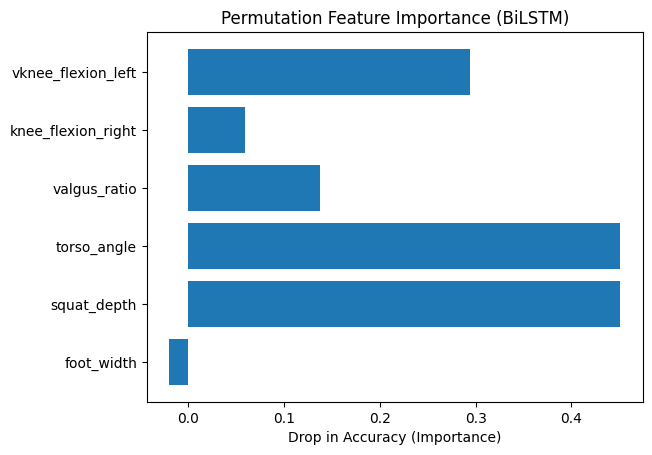

In [12]:

# Copy the original test set
X_test_copy = X_test.copy()
original_accuracy = final_model.evaluate(X_test_copy, y_test, verbose=0)[1]
print(f"Original test accuracy: {original_accuracy:.4f}")

# Feature names
feature_names = [
    "vknee_flexion_left",
    "knee_flexion_right",
    "valgus_ratio",
    "torso_angle",
    "squat_depth",
    "foot_width"
]

# Permutation importance
importances = []

for i in range(X_test.shape[2]):  # loop over features
    X_permuted = X_test_copy.copy()
    for seq in X_permuted:
        np.random.shuffle(seq[:, i])  # shuffle the i-th feature across time in each sequence

    permuted_acc = final_model.evaluate(X_permuted, y_test, verbose=0)[1]
    drop = original_accuracy - permuted_acc
    importances.append(drop)
    print(f"Feature '{feature_names[i]}' caused accuracy drop: {drop:.4f}")

plt.barh(feature_names, importances)
plt.xlabel("Drop in Accuracy (Importance)")
plt.title("Permutation Feature Importance (BiLSTM)")
plt.gca().invert_yaxis()
plt.show()
